In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
df = yf.download("TSLA",start="2017-1-1")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.columns = df.columns.get_level_values(0)

In [4]:
df.sample(5)

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-11-13,330.239990,344.600006,322.500000,335.850006,125405600
2018-02-21,22.219999,22.646000,22.211332,22.402000,48294000
2020-12-01,194.919998,199.283340,190.683334,199.196671,120310500
2026-03-19,380.299988,387.269989,378.730011,387.269989,67078300
2017-07-25,22.639999,23.040001,22.276667,23.000000,104838000


In [5]:
df["Open:10 days rolling"] = df["Open"].rolling(window=10,min_periods=1).mean()

In [6]:
df.sample(8)

Price,Close,High,Low,Open,Volume,Open:10 days rolling
Date,,,,,,
2024-09-06,210.729996,233.600006,210.509995,232.600006,112177000,215.655002
2026-02-24,409.380005,410.820007,397.640015,399.500000,58579500,413.645993
2021-04-08,227.933334,229.850006,223.883331,225.793335,71772900,218.987999
2020-04-22,48.807335,48.933334,45.914001,46.931999,212482500,45.356267
2026-07-31,311.209991,315.500000,301.970001,309.690002,36630600,333.317001
2019-10-14,17.130667,17.236668,16.475332,16.526667,153075000,15.970533
2023-09-18,265.279999,271.440002,263.760010,271.160004,101543300,262.156001
2018-06-27,22.966667,23.386000,22.633333,23.000000,125005500,23.365200


<Axes: xlabel='Date'>

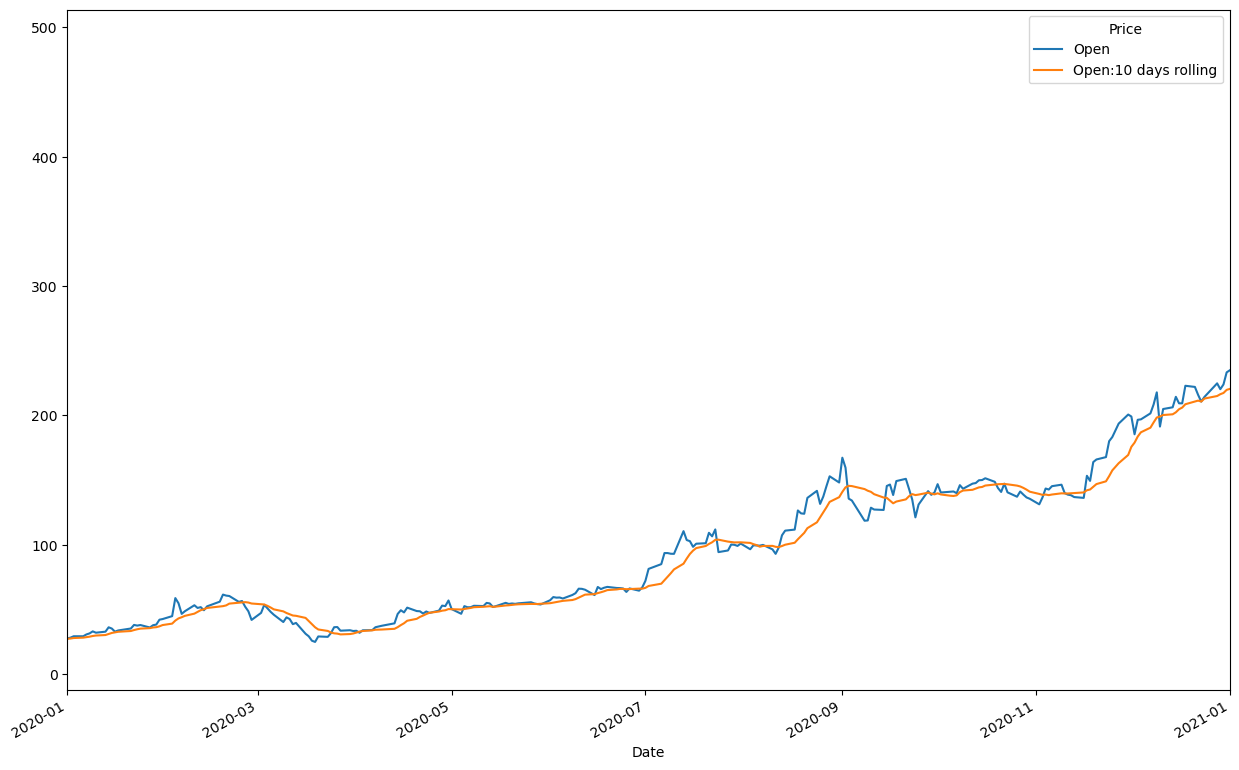

In [7]:
df[["Open","Open:10 days rolling"]].plot(xlim=["2020-1-1","2021-1-1"],figsize=(15, 10))

In [8]:
df["Open:30 days rolling"] = df["Open"].rolling(window=30,min_periods=1).mean()

<Axes: xlabel='Date'>

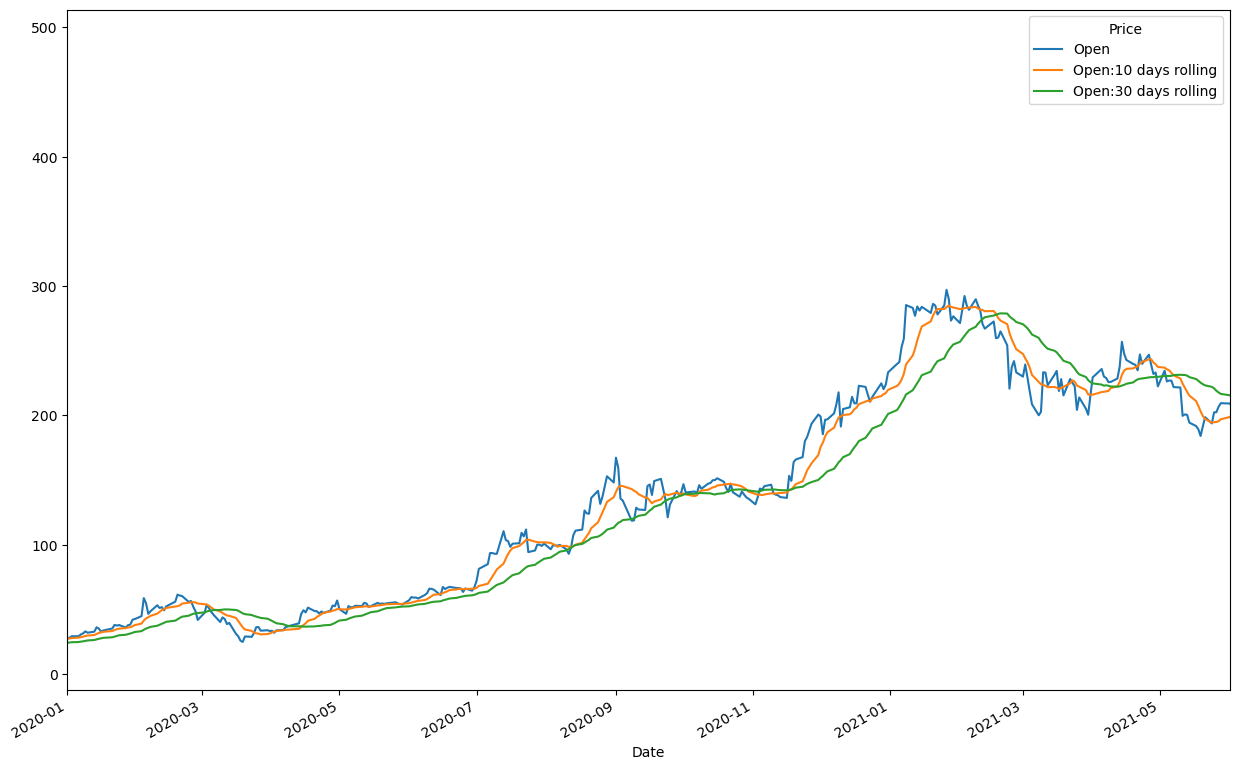

In [12]:
df[["Open","Open:10 days rolling","Open:30 days rolling"]].plot(xlim=["2020-1-1","2021-6-1"],figsize=(15,10))

In [16]:
df["CMA"] = df["Open"].expanding().mean()

<Axes: xlabel='Date'>

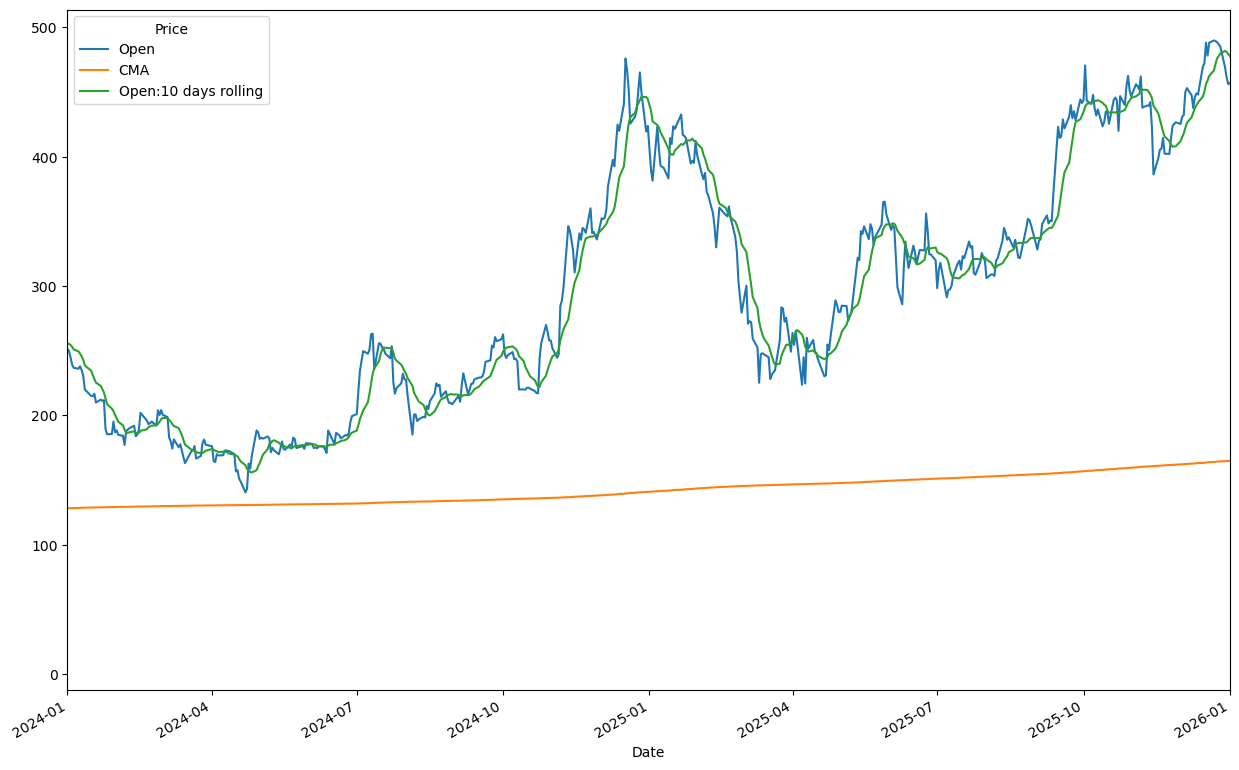

In [22]:
df[["Open","CMA","Open:10 days rolling"]].plot(xlim=["2024-1-1","2026-1-1"],figsize= (15,10))

<Axes: xlabel='Date'>

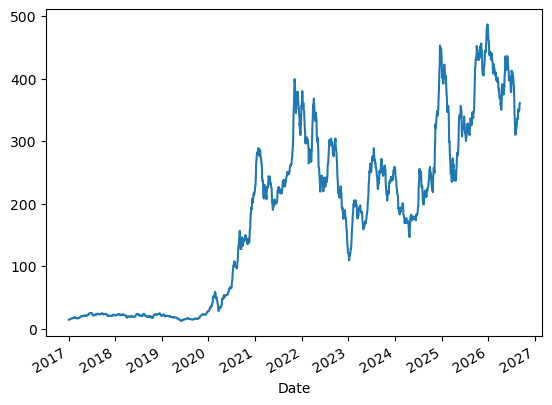

In [26]:
df["Open"].ewm(span=4).mean().plot()

In [32]:
df["ewm"] = df["Open"].ewm(span=5).mean()

<Axes: xlabel='Date'>

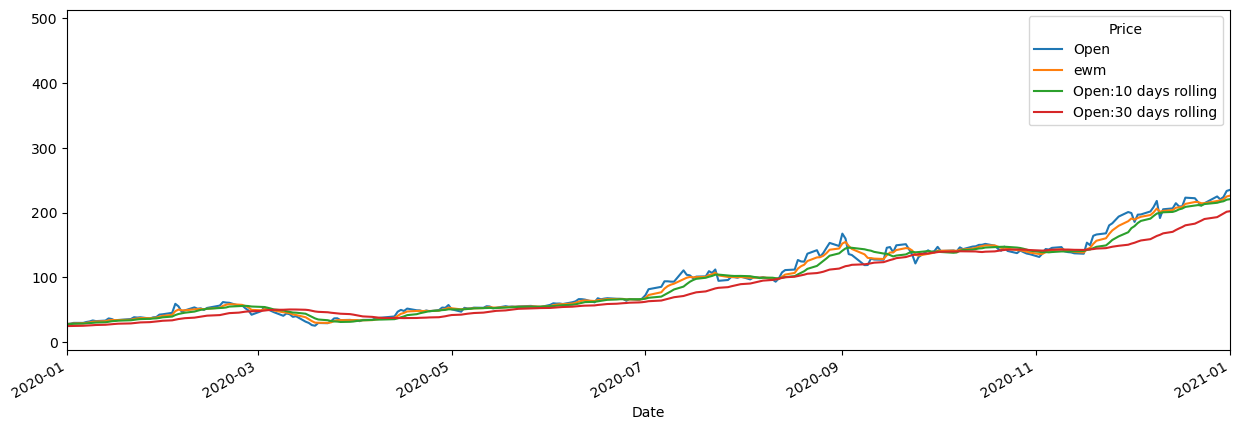

In [35]:
df[["Open","ewm","Open:10 days rolling","Open:30 days rolling"]].plot(xlim = ["2020-1-1","2021-1-1"],figsize = (15,5))